In [1]:
import pickle
import statistics

In [2]:
with open('/home/r15user3/Documents/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_A37_cell_pearson_list.pkl', 'rb') as f:
    multi_cell_pearson_list = pickle.load(f)
ensemble_mean = statistics.mean(multi_cell_pearson_list)
ensemble_mean

0.4265961482816393

In [3]:
ensemble_std = statistics.variance(multi_cell_pearson_list)
ensemble_std

0.03513971528298737

In [5]:
with open('/home/r15user3/Documents/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch2000_lr1e-4_GCN_onlycell_A37_cell_pearson_list.pkl', 'rb') as f:
    multi_cell_pearson_list = pickle.load(f)
gcn_mean = statistics.mean(multi_cell_pearson_list)
gcn_mean

0.3352690063875727

In [7]:
gcn_std = statistics.variance(multi_cell_pearson_list)
gcn_std

0.0430697233446159

In [8]:
with open('/home/r15user3/Documents/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_densenet_onlycell_A37_cell_pearson_list.pkl', 'rb') as f:
    multi_cell_pearson_list = pickle.load(f)
densenet_mean = statistics.mean(multi_cell_pearson_list)
densenet_mean

0.38831956413269797

In [9]:
densenet_std = statistics.variance(multi_cell_pearson_list)
densenet_std

0.04038362201806693

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the models
models = ['Hist2Cell', 'GNN', 'Transformer', 'STNet']
average_performance = [
    [ensemble_mean, gcn_mean, 0.20, densenet_mean],
    [0.5, 0.25, 0.20, 0.15],
    [0.4, 0.25, 0.20, 0.15],
    [0.35, 0.25, 0.20, 0.15],
]
standard_errors = [
    [ensemble_std, gcn_std, 0.07, densenet_std],
    [0.09, 0.08, 0.07, 0.07],
    [0.03, 0.08, 0.07, 0.07],
    [0.04, 0.08, 0.07, 0.07],
]
datasets = ['human lung', 'human breast 1', 'human breast 2', 'human breast']

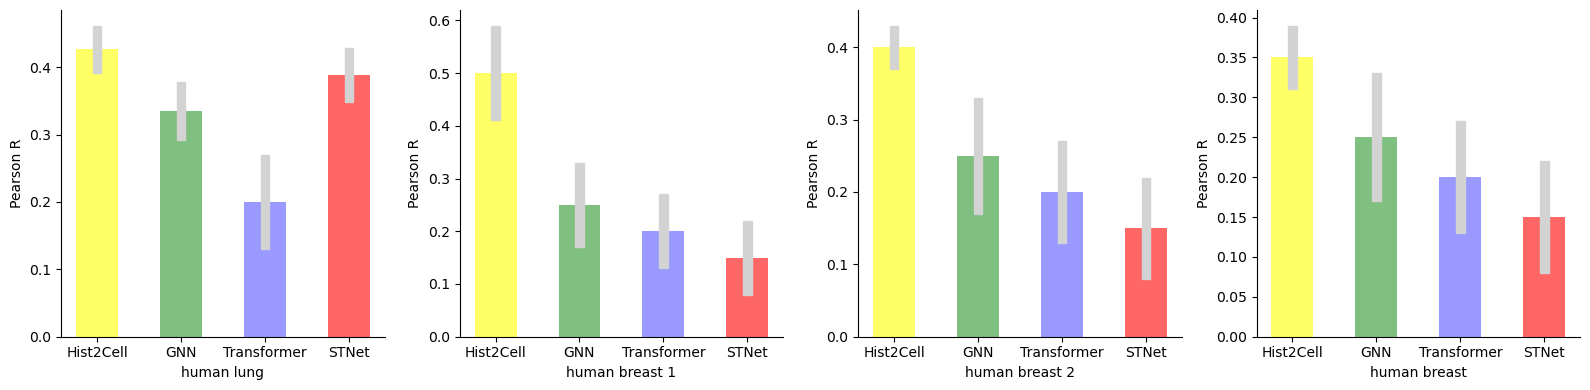

In [14]:
# Function to draw solid error bars
def draw_solid_error_bars(ax, x, y, errors, width=0.1, color='black'):
    for i in range(len(x)):
        rect = plt.Rectangle((x[i] - width / 2, y[i] - errors[i]), width, errors[i] * 2, color=color)
        ax.add_patch(rect)

# Create a 1x4 subplots layout with shared x and y axes
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

# Loop through each subplot and draw the bar plot
for i, ax in enumerate(axs):
    bar_plot = ax.bar(models[0], average_performance[i][0], align='center', alpha=0.6, color='yellow', width=0.5)
    bar_plot = ax.bar(models[1], average_performance[i][1], align='center', alpha=0.5, color='green', width=0.5)
    bar_plot = ax.bar(models[2], average_performance[i][2], align='center', alpha=0.4, color='blue', width=0.5)
    bar_plot = ax.bar(models[3], average_performance[i][3], align='center', alpha=0.6, color='red', width=0.5)
    ax.set_ylabel('Pearson R')
    ax.set_xlabel(datasets[i])

    ax.yaxis.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add solid error bars
    x_pos = np.arange(len(models))
    draw_solid_error_bars(ax, x_pos, average_performance[i], standard_errors[i], width=0.1, color='lightgray')

# Adjust the left and right margins of the subplots
plt.subplots_adjust(left=0.1, right=0.9)

# Save the figure and show
plt.tight_layout()
plt.show()